In [47]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# First column: experiment name, next three: interesting, rest ignored, no header
csv_path = '~/smt-napsat-conflicts.csv'  # Change this to your actual file path
cols = [0, 1, 2, 3]
df = pd.read_csv(csv_path, header=None, usecols=cols)
df.columns = ['experiment', "-rscb", "-ncb", "-gb"]

In [41]:
csv_path = '~/out.csv'
df = pd.read_csv(csv_path)
df.columns = ['experiment', "-rscb", "-ncb", "-gb", "-rscb-c", "-ncb-c", "-gb-c"]

In [42]:

# Calculate comparisons between "-ncb" and "-gb"
ncb_gt_gb = (df["-ncb"] > df["-gb"]).sum()
ncb_lt_gb = (df["-ncb"] < df["-gb"]).sum()
ncb_eq_gb = (df["-ncb"] == df["-gb"]).sum()
print(f"-ncb > -gb: {ncb_gt_gb}")
print(f"-ncb < -gb: {ncb_lt_gb}")
print(f"-ncb == -gb: {ncb_eq_gb}")

# Calculate the average difference between "-ncb" and "-gb"
avg_diff = (df["-ncb"] - df["-gb"]).mean()
print(f"Average difference (-ncb - -gb): {avg_diff}")

-ncb > -gb: 22782
-ncb < -gb: 8502
-ncb == -gb: 16495
Average difference (-ncb - -gb): 7.297620293434354


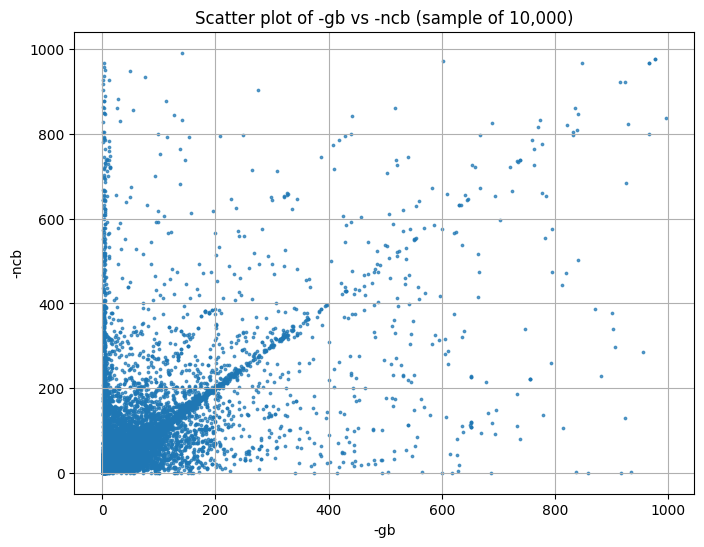

In [43]:

# Scatter plot between "-gb" and "-ncb" using a random sample of 10,000 rows
plot_sample = df.sample(n=100000, random_state=42) if len(df) > 100000 else df
plt.figure(figsize=(8, 6))
plt.scatter(plot_sample["-gb"], plot_sample["-ncb"], alpha=0.7, s=3)
plt.xlabel("-gb")
plt.ylabel("-ncb")
plt.title("Scatter plot of -gb vs -ncb (sample of 10,000)")
plt.grid(True)
plt.show()

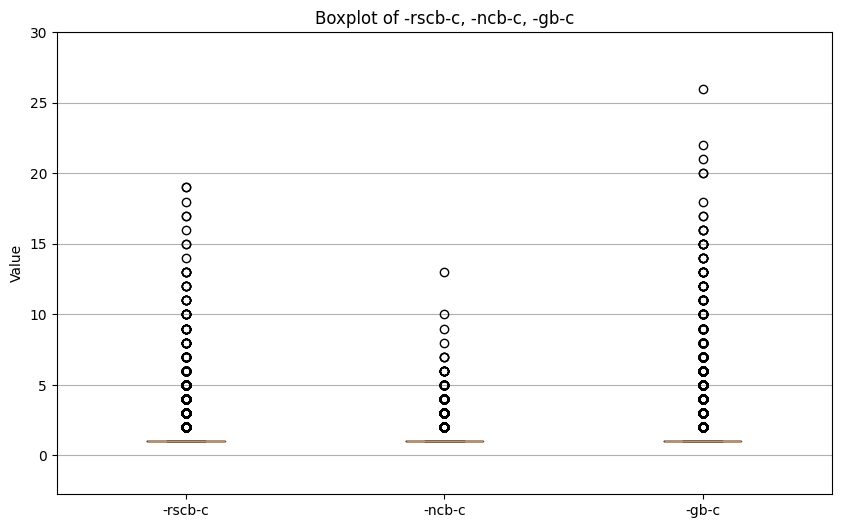

In [44]:

# Boxplot of the last three columns: -rscb-c, -ncb-c, -gb-c
plt.figure(figsize=(10, 6))
plt.boxplot([df["-rscb-c"], df["-ncb-c"], df["-gb-c"]], tick_labels=["-rscb-c", "-ncb-c", "-gb-c"])
plt.ylabel("Value")
plt.title("Boxplot of -rscb-c, -ncb-c, -gb-c")
plt.ylim(top=30)
plt.grid(True, axis='y')
plt.show()

In [45]:

# Print the average of the last three columns
avg_rscb_c = df["-rscb-c"].mean()
avg_ncb_c = df["-ncb-c"].mean()
avg_gb_c = df["-gb-c"].mean()
print(f"Average -rscb-c: {avg_rscb_c}")
print(f"Average -ncb-c: {avg_ncb_c}")
print(f"Average -gb-c: {avg_gb_c}")

Average -rscb-c: 1.1625818874400888
Average -ncb-c: 1.1027857426903032
Average -gb-c: 1.3659348249230834


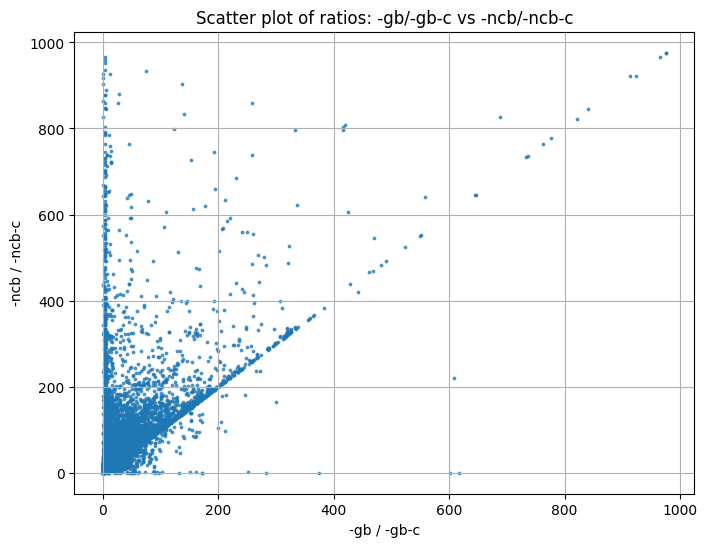

In [46]:

# Calculate ratios for -ncb/-ncb-c and -gb/-gb-c
ncb_ratio = df["-ncb"] / df["-ncb-c"]
gb_ratio = df["-gb"] / df["-gb-c"]

# Scatter plot of the two ratios
plt.figure(figsize=(8, 6))
plt.scatter(gb_ratio, ncb_ratio, alpha=0.7, s=3)
plt.xlabel("-gb / -gb-c")
plt.ylabel("-ncb / -ncb-c")
plt.title("Scatter plot of ratios: -gb/-gb-c vs -ncb/-ncb-c")
plt.grid(True)
plt.show()